In [1]:
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python matplotlib spacy
!python -m spacy download en_core_web_sm

zsh:1: command not found: apt-get
  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached pytesseract-0.3.13-py3-none-any.whl (14 kB)
Using cached opencv_p

In [2]:
import os
import kagglehub
base_path = kagglehub.dataset_download("aravindram11/funsdform-understanding-noisy-scanned-documents")

print(os.listdir(base_path))
print(os.listdir(base_path + "/training_data"))
print(os.listdir(base_path + "/training_data/images")[:5])

ModuleNotFoundError: No module named 'kagglehub'

(np.float64(-0.5), np.float64(776.5), np.float64(999.5), np.float64(-0.5))

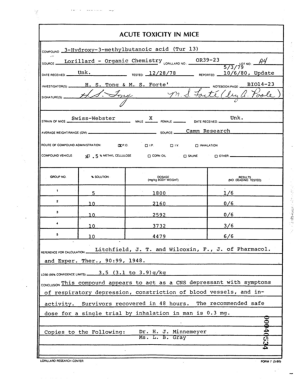

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = base_path + "/training_data/images/00040534.png"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(776.5), np.float64(999.5), np.float64(-0.5))

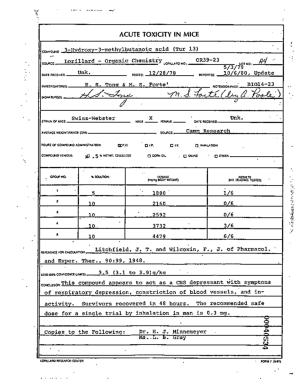

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

plt.imshow(thresh, cmap="gray")
plt.axis("off")

In [ ]:
import pytesseract

text = pytesseract.image_to_string(thresh)

print(text[:1000])

    

 

[ ACUTE TOXICITY IN MICE

 

9 3cHydroxy-3-methylbutanoic acid (Tux 13)

'

 

 

 

   

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

 

cowrosx
sonce_Lorillard - Organic Chemistry 24. juyug, _OR39-23 aro
B73/Te
ore rconn WOK vesne, 12/28/78 sevones, 20/6/80, Upéate
wesncarany H. §. Tong & M. 5, Forte! oreaogeenes_.BIOL4~23
pwns a 2 Poe gad Bath ( hin l Vote)
zo =
smn or nce, S¥iss-Webster reuse" care scene UB
sveage wasouTaANce sewer. Camm Research
rower cowouissounsieanor =O. ATO
JeowouDvEMCLE: 9 5 % Men. ceuuLone meee + omen
ore, sauro8
: 5,
2 10 0/6
: 10. “2592 0/6
‘ 10. . 3732 2 3/6.
* 10 4479 6/6

 

 

REFERENCE FOR CAE ATION

and Exper. Ther., 90:99, 1948.

Litchfield, J, T. and Wilcoxin, P., d. of Phaxmacol. *

 

nsopescomonceum 3-5 (3-1 to 3.9)a/kq

conausonThis compound appears to act as a CNS depressant With symptons
of respiratory depression, constriction of blood vessels, and in-
activity. Survivors recovered in 48 hours. The recommended safe

dose for a single

In [ ]:
import json

ann_path = base_path + "/training_data/annotations/00040534.json"

with open(ann_path) as f:
    data = json.load(f)

for item in data["form"]:
    print("TEXT:", item["text"])
    print("LABEL:", item["label"])
    print("-" * 30)

TEXT: COMPOUND
LABEL: question
------------------------------
TEXT: SOURCE
LABEL: question
------------------------------
TEXT: INVESTIGATOR(S)
LABEL: question
------------------------------
TEXT: SIGNATURE(S)
LABEL: question
------------------------------
TEXT: REPORTED
LABEL: question
------------------------------
TEXT: TESTED
LABEL: question
------------------------------
TEXT: MALE
LABEL: question
------------------------------
TEXT: FEMALE
LABEL: question
------------------------------
TEXT: SOURCE
LABEL: question
------------------------------
TEXT: Unk.
LABEL: answer
------------------------------
TEXT: P.O.
LABEL: question
------------------------------
TEXT: A4
LABEL: answer
------------------------------
TEXT: 12/28/78
LABEL: answer
------------------------------
TEXT: X
LABEL: answer
------------------------------
TEXT: Unk.
LABEL: answer
------------------------------
TEXT: Camm
LABEL: answer
------------------------------
TEXT: Research
LABEL: answer
---------------------

In [ ]:
structured_data = {}

for item in data["form"]:
    if item["label"] == "question":
        key = item["text"]
    elif item["label"] == "answer":
        value = item["text"]
        structured_data[key] = value

print(structured_data)

{'SOURCE': 'Unk.', 'P.O.': '4479', 'CONCLUSION': 'Lorillard - Organic Chemistry', 'LORILLARD NO': 'OR39- 23', 'DATE RECEIVED': 'B1014- 23', 'STRAIN OF MICE': 'Swiss- Webster', 'RESULTS (NO TESTED)': '6/ 6', 'REFERENCE FOR CALCULATION': 'Dr. H. J. Minnemeyer Ms. L. B. Gray', 'Copies to the Following:': 'This compound appears to act as a CNS depressant with symptons'}


(np.float64(-0.5), np.float64(776.5), np.float64(999.5), np.float64(-0.5))

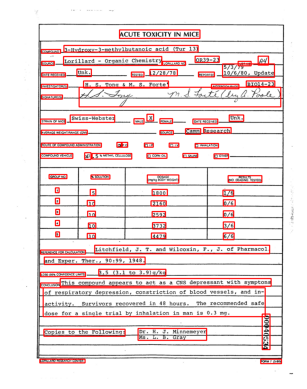

In [ ]:
for item in data["form"]:
    x1, y1, x2, y2 = item["box"]
    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

plt.imshow(img)
plt.axis("off")

In [ ]:
keywords = ["total", "amount", "date", "due", "payment"]

for item in data["form"]:
    text = item["text"].lower()
    
    for k in keywords:
        if k in text:
            print("⚠️ Important:", item["text"])

⚠️ Important: DATE RECEIVED
⚠️ Important: 5/3/79 10/6/80 , Update
⚠️ Important: DATE RECEIVED


In [ ]:
print("OCR TEXT:\n", text[:300])
print("\nGROUND TRUTH:\n", [item["text"] for item in data["form"][:10]])

OCR TEXT:
 ld50 (95% confidence limits)

GROUND TRUTH:
 ['COMPOUND', 'SOURCE', 'INVESTIGATOR(S)', 'SIGNATURE(S)', 'REPORTED', 'TESTED', 'MALE', 'FEMALE', 'SOURCE', 'Unk.']
